# (21) mlp decoder

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'MNIST', 'ngd|mlp')

t_train = 10

cfg_vae['t_train'] = t_train
cfg_vae['beta_outer'] = 4/8 * t_train

cfg_vae['track_stats'] = True

cfg_tr['epochs'] = 400

In [4]:
cfg_vae['recon_mode'] = 'mse'
cfg_vae['fit_dec_sigma'] = False

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  567.1 K   |
|     ———     |    ———     |
|    layer    |  567.1 K   |
+-------------+------------+

poisson_MNIST_t-10_b-5_k-[128]_u-8,du-7
b200-ep400-lr(0.002)_temp(0.01:0.5)_gr(3000)_(2025_05_22,17:40)

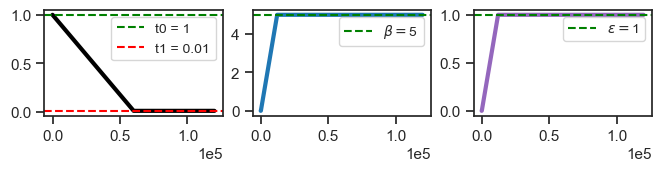

In [5]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
tr.print()
tr.show_schedules()

In [6]:
tr.n_iters

120000

In [7]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'prior_log_dist': 'uniform', 'clamp_prior': -2, 't_train': 10, 'n_iters_outer': 1, 'n_iters_inner': 1, 'dataset': 
'MNIST', 'dataset_name': 'MNIST', 'feeder': 'stationary', 'feeder_cfg': {}, 'input_sz': (1, 28, 28), 'shape': (-1, 
1, 28, 28), 'beta_inner': 1.0, 'beta_outer': 5.0, 'n_latents': [128], 'enc_type': 'ngd', 'dec_type': 'mlp', 
'clamp_u': 8.0, 'clamp_du': 7.0, 'recon_mode': 'mse', 'fit_dec_sigma': False, 'fit_prior': True, 'stochastic': 
True, 'init_dist': 'normal', 'init_scale': 0.05, 'seed': 0, 'track_stats': True, 'base_dir': 
'/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/poisson_MNIST_t-10_b-5_k-[128]_u-8,du-7', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_MNIST_t-10_b-5_k-[128]_u-8,du-7', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.002, 'epochs': 400, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0003, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 398.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 
3000, 'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_balancer': None, 
'kl_time_adjuster': None, 'kl_anneal_cycles': 0, 'kl_anneal_portion': 0.1, 'kl_const_portion': 0.001, 
'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 0.01}

In [8]:
cm = 'CloneTransition'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 400, avg loss: 20.225: 100%|████████| 400/400 [1:46:06<00:00, 15.92s/it]


In [9]:
tr.model.layer.bias

Parameter containing:
tensor([[-2.4400e-04,  1.1690e-02,  3.0869e-03,  1.2035e-02,  7.5774e-02,
          4.8432e-02,  1.8803e-03,  3.2556e-02,  8.7546e-04, -9.9000e-04,
          5.6992e-02,  2.7623e-03,  3.7971e-03, -1.3378e-03,  4.6767e-02,
          1.3835e-02,  8.4466e-04,  3.3880e-03, -3.4800e-04,  1.4404e-02,
          2.4850e-03,  4.6148e-03,  4.0858e-02,  6.5242e-03,  3.0721e-02,
          6.1733e-03,  3.5312e-02,  1.6020e+00,  4.3160e-02, -2.9137e-03,
          2.8979e-03,  2.3328e-02,  1.2138e-02, -5.3316e-04,  4.5917e-03,
          1.5578e-02,  3.6489e-02,  3.1902e-02,  5.7712e-02,  7.1079e-03,
          4.2334e-02,  5.8447e-05,  3.1354e-04,  2.5125e-02, -1.6813e-03,
          2.0970e-03,  9.8705e-03,  1.1324e-02,  8.1488e-03,  8.8621e-02,
          1.1169e-03,  8.8268e-05,  1.6566e-03, -1.9957e-04,  2.1365e-03,
          5.5950e-03,  9.3254e-03,  7.8713e-03,  1.9920e-03,  3.9336e-03,
          1.3386e-03,  4.9074e-03,  3.5364e-03,  2.8174e-03,  1.4550e-02,
          8.5250

In [10]:
print(tr.model.layer.n_exp)

tensor([21, 24, 26, 28, 30, 32, 33, 34, 35, 36], device='cuda:1',
       dtype=torch.int32)

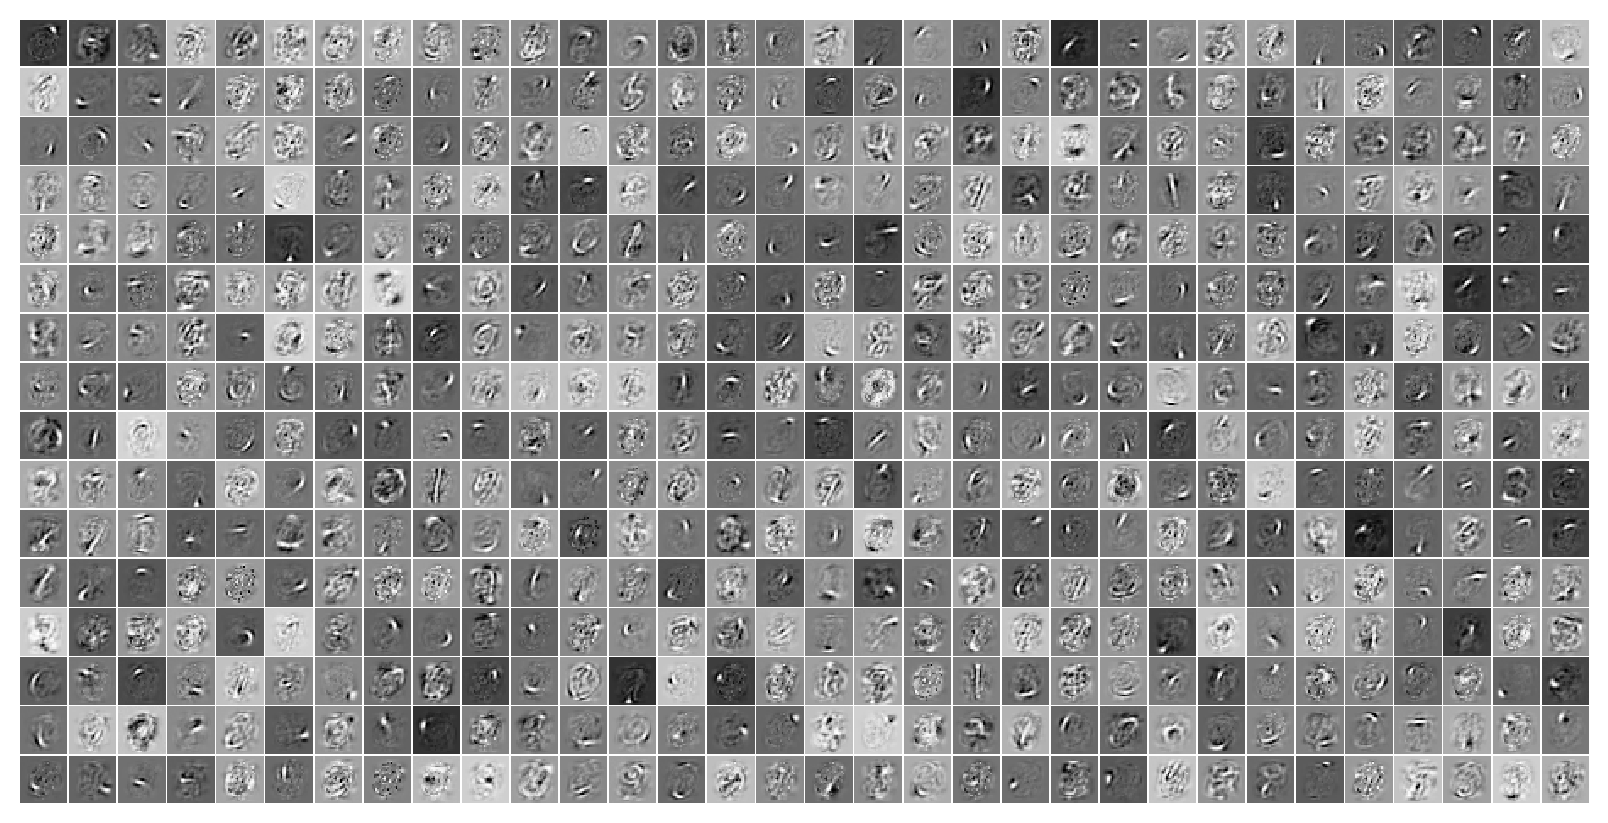

In [11]:
tr.model.show(method='min-max');

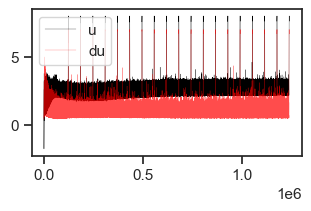

In [12]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

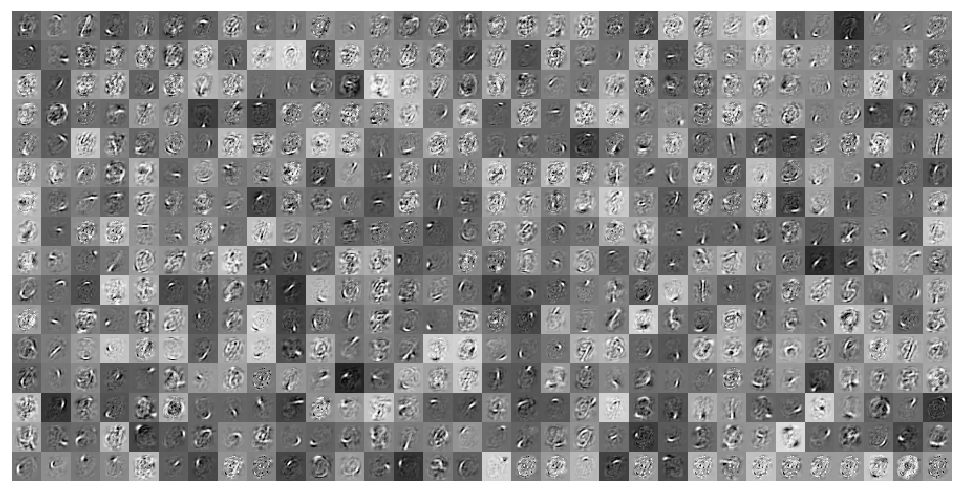

In [13]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=0))
tr.model.show(order=np.argsort(norms), dpi=120, pad=0);

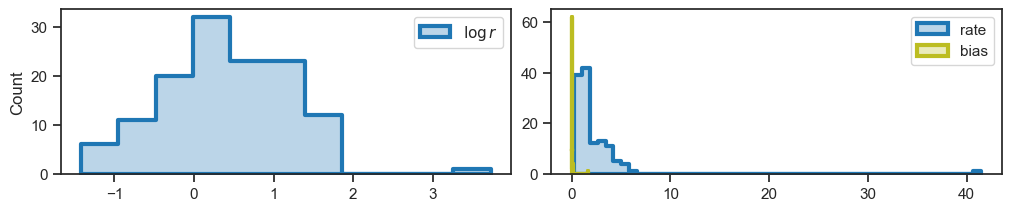

In [14]:
log_rate = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.bias).ravel()

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [15]:
histplot(u0, bins=80, color='dimgrey');

NameError: name 'u0' is not defined

In [ ]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())

In [ ]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

In [16]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

ValueError: cannot reshape array of size 784 into shape (16,16)

In [ ]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## Normal gold standard

Was obtained with ```loss_per_dim = False```

In [ ]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16', 'grad|lin')

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 16.0

In [ ]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [ ]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

In [ ]:
print(tr.model.layer)
print(tr.model.layer.n_exp)

In [ ]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

In [ ]:
tr.train()

In [ ]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

In [ ]:
print(tr.model.layer.n_exp)

In [ ]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [ ]:
histplot(u0, color='dimgrey');

In [ ]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

In [ ]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

In [ ]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

In [ ]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [ ]:
### Was: (not) loss per dim

In [ ]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=['u', 'v', 'conditional'],
).stack()

In [ ]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

In [ ]:
### Was: beta = 20.0

In [ ]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)

samples = torch.stack([
    p.sample() for p in
    output['conditional'].values()
], dim=1)

mse_locs = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
mse_samples = (samples - feeder[0].unsqueeze(1)).pow(2).sum(-1)

fig, ax = create_figure()
ax.plot(tonp(mse_locs.mean(0)), color='k', label='mean')
ax.plot(tonp(mse_samples.mean(0)), color='tomato', label='sample')
ax.set_yscale('log')
add_legend(ax)
plt.show()

mse_locs.mean(0)[-5:], mse_samples.mean(0)[-5:]

In [ ]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

In [ ]:
x2p = tonp(samples)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)